In [20]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [21]:
# Load the dataset
df = pd.read_csv('../datasets/Training.csv')

In [22]:
# Encoding the labels for prognosis
le = LabelEncoder()
df['prognosis'] = le.fit_transform(df['prognosis'])

In [23]:
# Splitting features (X) and labels (y)
X = df.drop(columns=['prognosis'])
y = df['prognosis']

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
print("Training set class distribution:", np.bincount(y_train))
print("Validation set class distribution:", np.bincount(y_val))
print("Test set class distribution:", np.bincount(y_test))


Training set class distribution: [84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84
 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84 84]
Validation set class distribution: [18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18
 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18]
Test set class distribution: [18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18
 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18 18]


In [25]:
# Print the sizes
print("Training set size:", X_train.shape[0])  # 70% of total
print("Validation set size:", X_val.shape[0])  # 15% of total
print("Test set size:", X_test.shape[0])  # 15% of total

Training set size: 3444
Validation set size: 738
Test set size: 738


In [26]:

# Reshape data to fit RNN input requirements
# RNNs require 3D input: (samples, timesteps, features)
X_train = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val = X_val.values.reshape(X_val.shape[0], 1, X_val.shape[1])
X_test = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])


In [27]:
# Add jitter to numerical features
jitter_factor = 0.01
X_train_augmented = X_train + jitter_factor * np.random.uniform(-1, 1, X_train.shape)

In [28]:
model = Sequential()
model.add(SimpleRNN(128, activation='tanh', return_sequences=True, 
                    input_shape=(1, X_train.shape[2]), 
                    kernel_regularizer=l2(0.02))) 
model.add(BatchNormalization())
model.add(Dropout(0.5)) 
model.add(SimpleRNN(64, activation='tanh', kernel_regularizer=l2(0.02)))
model.add(BatchNormalization())
model.add(Dropout(0.5)) 
model.add(Dense(len(np.unique(y)), activation='softmax'))

c:\Users\pavan\Downloads\capstone dataset\myenv\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [30]:
# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [31]:
# Early stopping and learning rate reduction callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)

In [32]:
# Train the model with validation data
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.2347 - loss: 7.1530 - val_accuracy: 1.0000 - val_loss: 4.4334 - learning_rate: 0.0010
Epoch 2/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9025 - loss: 3.3980 - val_accuracy: 1.0000 - val_loss: 2.4630 - learning_rate: 0.0010
Epoch 3/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9725 - loss: 2.0467 - val_accuracy: 1.0000 - val_loss: 1.4297 - learning_rate: 0.0010
Epoch 4/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9925 - loss: 1.2436 - val_accuracy: 1.0000 - val_loss: 0.8416 - learning_rate: 0.0010
Epoch 5/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9956 - loss: 0.7478 - val_accuracy: 1.0000 - val_loss: 0.5061 - learning_rate: 0.0010
Epoch 6/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9970 - loss: 0.4647 - val_accuracy: 1.0000 - val_loss: 0.3128 - learning_rate: 0.0010
Epoch 7/50
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9966 - loss: 0.3096 -

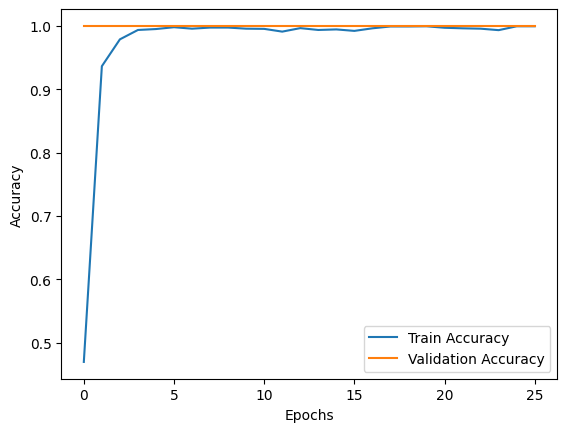

In [33]:
import matplotlib.pyplot as plt

# Assuming you have history object from model training
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [34]:
# Predict using the test data
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


In [35]:
# Print sample predictions (first 5)
for i in range(5):
    print(f"Actual: {le.inverse_transform([y_test.iloc[i]])[0]}, Predicted: {le.inverse_transform([predicted_classes[i]])[0]}")

Actual: Hepatitis E, Predicted: Hepatitis E
Actual: Paralysis (brain hemorrhage), Predicted: Paralysis (brain hemorrhage)
Actual: Chicken pox, Predicted: Chicken pox
Actual: GERD, Predicted: GERD
Actual: (vertigo) Paroymsal  Positional Vertigo, Predicted: (vertigo) Paroymsal  Positional Vertigo


In [36]:
model.save('medical_recommendation.h5')

In [37]:
from tensorflow.keras.models import load_model

# Load model
svc = load_model('medical_recommendation.h5')


In [39]:
predicted_class = svc.predict(X_test[0:1]).argmax()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [40]:
sym_des = pd.read_csv('../datasets/symtoms_df.csv')
precautions = pd.read_csv('../datasets/precautions_df.csv')
workout = pd.read_csv('../datasets/workout_df.csv')
description = pd.read_csv('../datasets/description.csv')
medications = pd.read_csv('../datasets/medications.csv')
diets = pd.read_csv('../datasets/diets.csv')

In [41]:
# model prediction function
def helper(dis):
    desc = description[description['Disease'] == predicted_disease]['Description']
    desc = " ".join([w for w in desc])

    pre = precautions[precautions['Disease'] == dis][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    pre = [col for col in pre.values]

    med = medications[medications['Disease'] == dis]['Medication']
    med = [med for med in med.values]

    die = diets[diets['Disease'] == dis]['Diet']
    die = [die for die in die.values]

    wrkout = workout[workout['disease'] == dis] ['workout']


    return desc,pre,med,die,wrkout

symptoms_dict = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

def get_predicted_value(patient_symptoms):
    input_vector = np.zeros(len(symptoms_dict))  # Initialize the input vector
    for item in patient_symptoms:
        if item in symptoms_dict:  # Ensure symptom exists in the dictionary
            input_vector[symptoms_dict[item]] = 1
    
    # Reshape input to (1, 1, len(symptoms_dict)) for 3D input compatibility
    input_vector = input_vector.reshape(1, 1, -1)
    
    # Use the model to predict and return the disease
    predicted_class = np.argmax(svc.predict(input_vector), axis=-1)[0]  # Use axis=-1 for the correct dimension
    return diseases_list[predicted_class]  # Map index to disease name



In [42]:
import numpy as np
symptoms = input("Enter your symptoms.......")
user_symptoms = [s.strip() for s in symptoms.split(',')]
user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]
predicted_disease = get_predicted_value(user_symptoms)

desc, pre, med, die, wrkout = helper(predicted_disease)

print("=================predicted disease============")
print(predicted_disease)
print("=================description==================")
print(desc)
print("=================precautions==================")
i = 1
for p_i in pre[0]:
    print(i, ": ", p_i)
    i += 1

print("=================medications==================")
for m_i in med:
    print(i, ": ", m_i)
    i += 1

print("=================workout==================")
for w_i in wrkout:
    print(i, ": ", w_i)
    i += 1

print("=================diets==================")
for d_i in die:
    print(i, ": ", d_i)
    i += 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
=================predicted disease============
Fungal infection
=================description==================
Fungal infection is a common skin condition caused by fungi.
=================precautions==================
1 :  bath twice
2 :  use detol or neem in bathing water
3 :  keep infected area dry
4 :  use clean cloths
=================medications==================
5 :  ['Antifungal Cream', 'Fluconazole', 'Terbinafine', 'Clotrimazole', 'Ketoconazole']
=================workout==================
6 :  Avoid sugary foods
7 :  Consume probiotics
8 :  Increase intake of garlic
9 :  Include yogurt in diet
10 :  Limit processed foods
11 :  Stay hydrated
12 :  Consume green tea
13 :  Eat foods rich in zinc
14 :  Include turmeric in diet
15 :  Eat fruits and vegetables
=================diets==================
16 :  ['Antifungal Diet', 'Probiotics', 'Garlic', 'Coconut oil', 'Turmeric']
